In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 定义模型架构 (需与训练时完全一致) =================
class TransformerSituationPredictor(nn.Module):
    def __init__(self, input_dim=10, d_model=64, nhead=4, num_layers=2):
        super(TransformerSituationPredictor, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, input_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: [Batch, Window_Size, Channels]
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :] # 取最后一个时隙的输出进行预测
        return self.sigmoid(self.fc_out(x))

# ================= 2. 实测数据预处理逻辑 =================
def process_real_world_to_transformer(dat_path="rx_captured_cleaned.dat"):
    FS = 500e3
    SAMPLES_PER_STEP = int(FS * 0.05) # 25,000点
    NUM_CHANNELS = 10
    WINDOW_SIZE = 12  # 预测步长：用过去12个时隙预测下1个
    
    # 加载清理后的信号
    rx_data = np.fromfile(dat_path, dtype=np.complex64)
    num_steps = len(rx_data) // SAMPLES_PER_STEP
    
    print(f"🔄 正在转换 {num_steps} 个时隙为态势特征向量...")
    
    # 模拟 MBF-PLENet 的感知过程：FFT能量映射
    sit_matrix = []
    for i in range(num_steps):
        iq_slice = rx_data[i*SAMPLES_PER_STEP : (i+1)*SAMPLES_PER_STEP]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(iq_slice)))
        # 划分为10个信道并计算平均能量
        ch_energies = [np.mean(e) for e in np.array_split(fft_mag, NUM_CHANNELS)]
        # 归一化并二值化 (阈值根据你之前的幅度 0.4 设定为 0.1)
        sit_vector = [1.0 if e > 0.1 else 0.0 for e in ch_energies]
        sit_matrix.append(sit_vector)
    
    sit_matrix = np.array(sit_matrix) # Shape: [Steps, 10]
    
    # 构建滑窗输入样本
    X_test = []
    for i in range(len(sit_matrix) - WINDOW_SIZE):
        X_test.append(sit_matrix[i : i + WINDOW_SIZE])
        
    return torch.FloatTensor(np.array(X_test)), sit_matrix

# ================= 3. 执行推理与可视化 =================
def run_real_world_inference():
    # 1. 准备数据
    X_input, raw_sit_matrix = process_real_world_to_transformer()
    
    # 2. 加载训练好的权重 (假设你已保存为 model.pth)
    model = TransformerSituationPredictor()
    # model.load_state_dict(torch.load('transformer_model.pth')) 
    model.eval()
    
    # 3. 执行预测
    print(f"🔮 正在对实测态势进行推理预测...")
    with torch.no_grad():
        predictions = model(X_input).numpy()
    
    # 4. 可视化对比图
    plt.figure(figsize=(15, 8))
    
    # 选取前 50 个预测结果展示
    show_len = 50
    
    plt.subplot(2, 1, 1)
    sns.heatmap(raw_sit_matrix[12:12+show_len].T, cmap="Blues", cbar=False, linewidths=0.5)
    plt.title("A: 实测感知态势 (Ground Truth from RX)", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    
    plt.subplot(2, 1, 2)
    # 将概率大于 0.5 的判定为干扰占用
    pred_binary = (predictions > 0.5).astype(float)
    sns.heatmap(pred_binary[:show_len].T, cmap="Reds", cbar=False, linewidths=0.5)
    plt.title("B: Transformer 未来时刻预测结果", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    plt.xlabel("演化时间步 (Step)")
    
    plt.tight_layout()
    plt.savefig("real_world_prediction_contrast.png", dpi=300)
    plt.show()
    
    print(f"✅ 预测热力图已保存。2515个样本共产生 {len(X_input)} 组连续演化预测。")

if __name__ == "__main__":
    run_real_world_inference()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📡 正在载入清理后的实测信号: rx_captured_cleaned.dat...
📊 总样本数: 2515 | 覆盖时长: 125.75 秒
🌈 正在生成前 10 秒的瀑布图...


🔥 正在提取态势特征矩阵...
✅ 质量监测报告已生成: real_world_quality_check.png


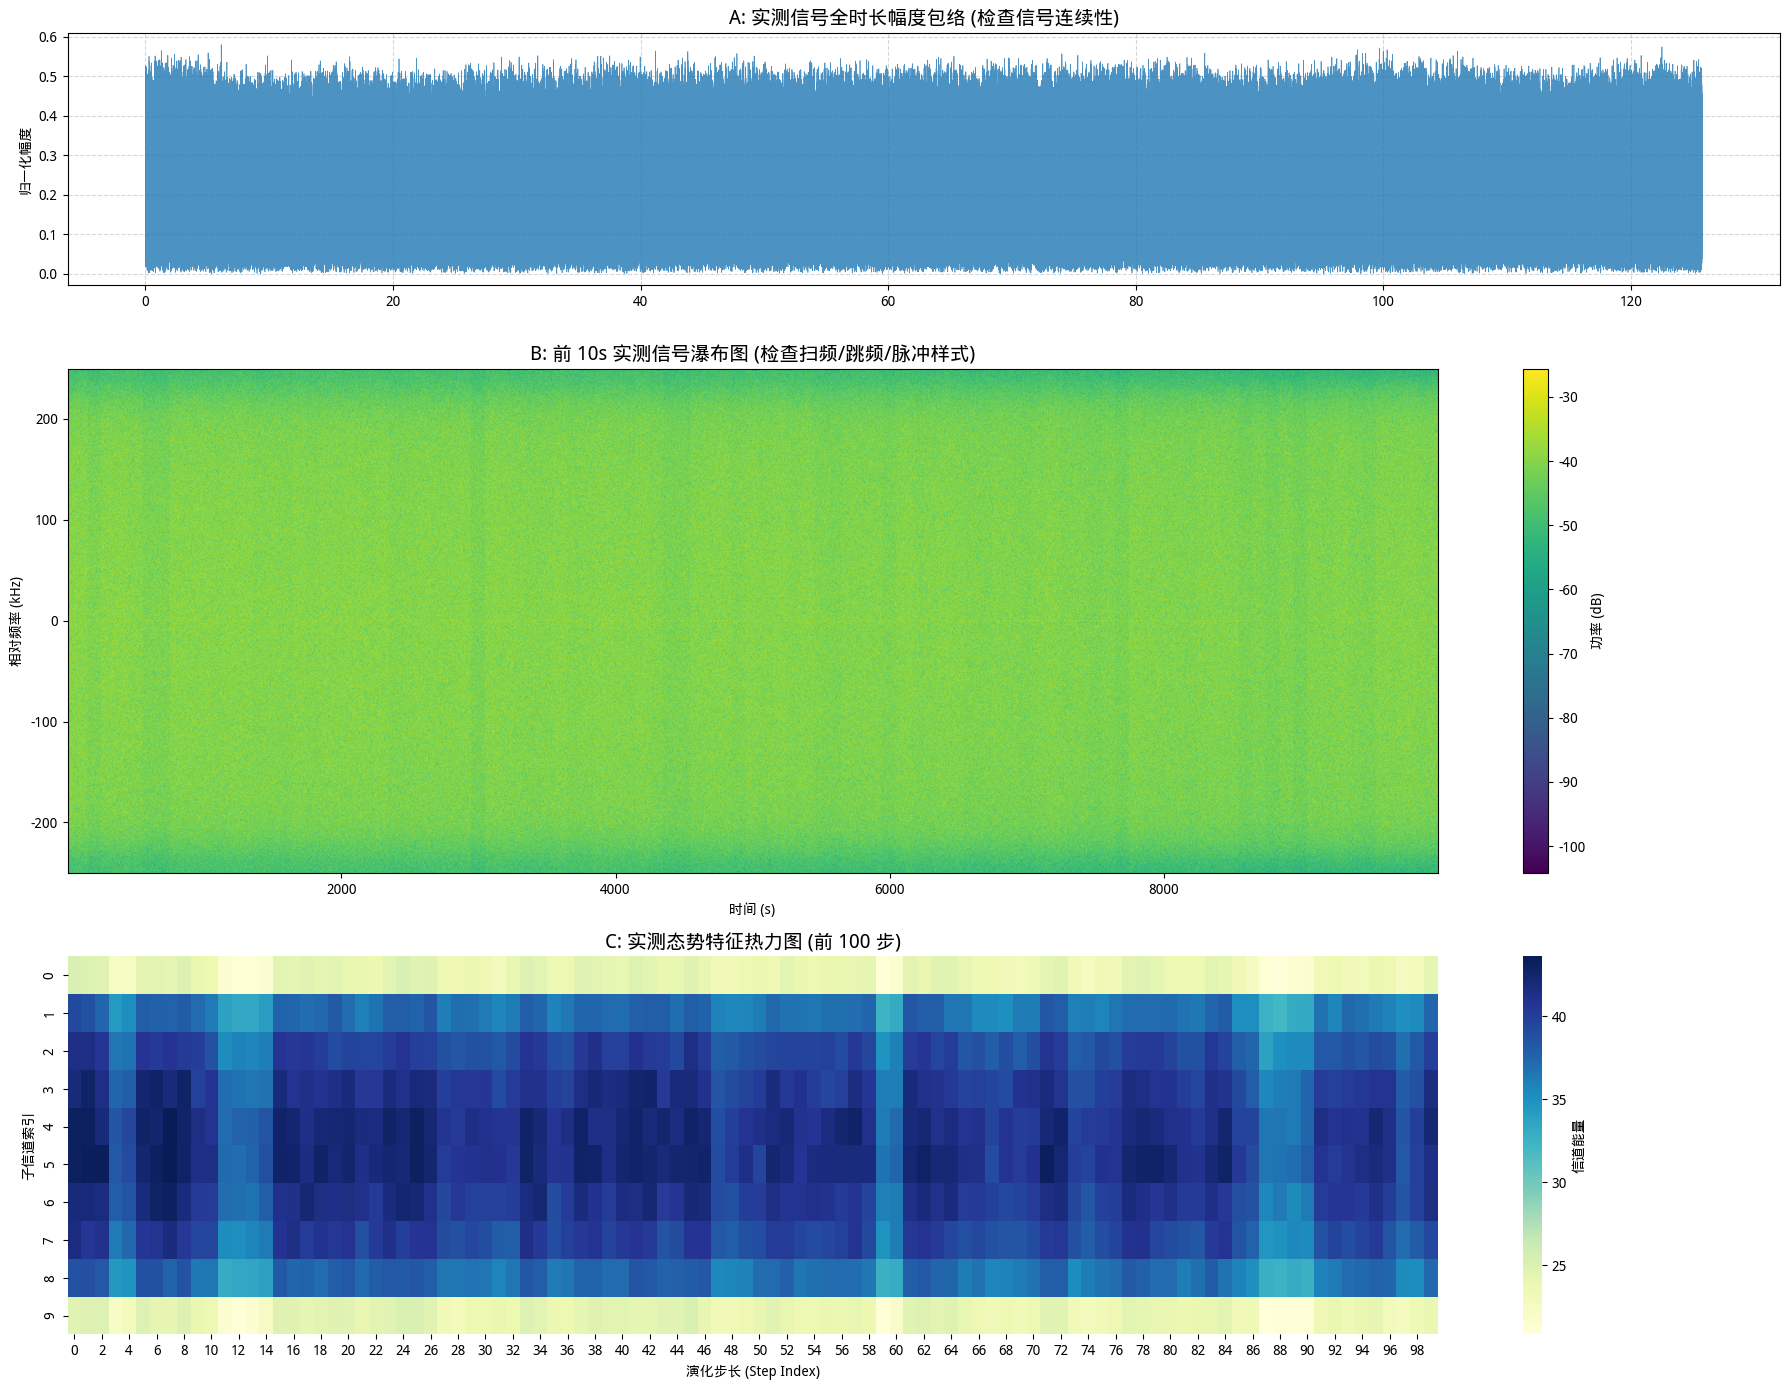

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def monitor_captured_quality(filename="rx_captured_cleaned.dat"):
    # ================= 1. 参数配置 =================
    FS = 500e3           # 采样率 500kHz
    STEP_DUR = 0.05      # 态势步长 50ms
    SAMPLES_PER_STEP = int(FS * STEP_DUR) # 25,000 点
    NUM_CHANNELS = 10
    
    # ================= 2. 加载数据 =================
    print(f"📡 正在载入清理后的实测信号: {filename}...")
    data = np.fromfile(filename, dtype=np.complex64)
    total_steps = len(data) // SAMPLES_PER_STEP
    print(f"📊 总样本数: {total_steps} | 覆盖时长: {len(data)/FS:.2f} 秒")

    # 创建画布
    fig = plt.figure(figsize=(18, 14))
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 2, 1.5])

    # --- 维度 A: 全局时域包络 (检查是否有断裂或幅度突变) ---
    ax0 = plt.subplot(gs[0])
    # 降低采样率绘图以加快速度
    downsample = 100
    amplitude = np.abs(data[::downsample])
    time_axis = np.arange(len(amplitude)) * downsample / FS
    ax0.plot(time_axis, amplitude, color='#1f77b4', lw=0.5, alpha=0.8)
    ax0.set_title("A: 实测信号全时长幅度包络 (检查信号连续性)", fontsize=14, fontweight='bold')
    ax0.set_ylabel("归一化幅度")
    ax0.grid(True, linestyle='--', alpha=0.5)

    # --- 维度 B: 时频谱/瀑布图 (检查干扰模式是否完整) ---
    ax1 = plt.subplot(gs[1])
    # 选取一段典型数据展示 (如前 10 秒)
    show_sec = 10 
    show_samples = int(FS * show_sec)
    print(f"🌈 正在生成前 {show_sec} 秒的瀑布图...")
    
    power_spectrogram, freqs, times, im = ax1.specgram(
        data[:show_samples], 
        NFFT=1024, 
        Fs=FS/1e3, 
        noverlap=512, 
        cmap='viridis'
    )
    ax1.set_title(f"B: 前 {show_sec}s 实测信号瀑布图 (检查扫频/跳频/脉冲样式)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("相对频率 (kHz)")
    ax1.set_xlabel("时间 (s)")
    plt.colorbar(im, ax=ax1, label='功率 (dB)')

    # --- 维度 C: 态势占用特征热力图 (检查 MBF-PLENet 感知一致性) ---
    ax2 = plt.subplot(gs[2])
    print("🔥 正在提取态势特征矩阵...")
    # 只取前 100 步进行可视化
    plot_steps = min(100, total_steps)
    sit_matrix = []
    for i in range(plot_steps):
        iq_slice = data[i*SAMPLES_PER_STEP : (i+1)*SAMPLES_PER_STEP]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(iq_slice)))
        # 映射到10个信道
        ch_energies = [np.mean(e) for e in np.array_split(fft_mag, NUM_CHANNELS)]
        sit_matrix.append(ch_energies)
    
    sit_matrix = np.array(sit_matrix).T # 转置方便 Heatmap 显示
    sns.heatmap(sit_matrix, cmap="YlGnBu", ax=ax2, cbar_kws={'label': '信道能量'})
    ax2.set_title(f"C: 实测态势特征热力图 (前 {plot_steps} 步)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("演化步长 (Step Index)")
    ax2.set_ylabel("子信道索引")

    plt.tight_layout()
    plt.savefig("real_world_quality_check.png", dpi=300)
    print("✅ 质量监测报告已生成: real_world_quality_check.png")
    plt.show()

if __name__ == "__main__":
    monitor_captured_quality()